In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
PATH = "../data/raw/diabetic_data.csv"
df = pd.read_csv(PATH, keep_default_na=False, na_values=["?"])
df.head()

/var/folders/xw/rszf3b9s743gf9r5lnm2yxbm0000gn/T/ipykernel_28322/186521055.py:5: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH, keep_default_na=False, na_values=["?"])


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [23]:
df["age"].unique()

<StringArray>
[  '[0-10)',  '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',
  '[60-70)',  '[70-80)',  '[80-90)', '[90-100)']
Length: 10, dtype: str

In [4]:
df.count(axis=0)

encounter_id                101766
patient_nbr                 101766
race                         99493
gender                      101766
age                         101766
weight                        3197
admission_type_id           101766
discharge_disposition_id    101766
admission_source_id         101766
time_in_hospital            101766
payer_code                   61510
medical_specialty            51817
num_lab_procedures          101766
num_procedures              101766
num_medications             101766
number_outpatient           101766
number_emergency            101766
number_inpatient            101766
diag_1                      101745
diag_2                      101408
diag_3                      100343
number_diagnoses            101766
max_glu_serum               101766
A1Cresult                   101766
metformin                   101766
repaglinide                 101766
nateglinide                 101766
chlorpropamide              101766
glimepiride         

In [5]:
df = df.replace("Unknown/Invalid", np.nan)
df["A1Cresult"].value_counts(dropna=False)

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [6]:
df.nunique()

encounter_id                101766
patient_nbr                  71518
race                             5
gender                           2
age                             10
weight                           9
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      17
medical_specialty               72
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         716
diag_2                         748
diag_3                         789
number_diagnoses                16
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

### Braki

In [7]:
print("amount of None")
p = df.isna().sum()
p[p > 0].sort_values(ascending=False)

amount of None


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
gender                   3
dtype: int64

In [8]:
s = df.isna().mean()
print("procentage of None")
s[s > 0].sort_values(ascending=False)

procentage of None


weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
gender               0.000029
dtype: float64

### target 

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

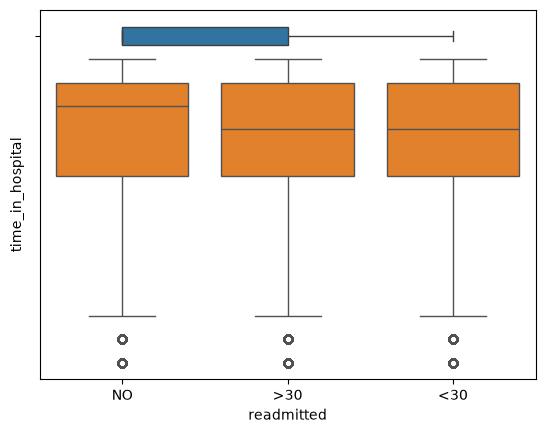

In [9]:
sns.boxplot(x="readmitted", data=df)
sns.boxplot(x="readmitted", y="time_in_hospital", data=df)

#### We have to change the target to 0,1 binar

In [19]:
df["target"] = (df["readmitted"] == "<30").astype(int)

df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

### Kohorta — kogo w ogóle badamy

Dwie decyzje **przed** liczeniem statystyk. Każda liczba w EDA opisuje konkretny zbiór —
gdy zbiór się zmienia, wcześniejsze liczby są nieaktualne.

In [11]:
DEAD_OR_HOSPICE = [11, 13, 14, 19, 20, 21]

mask_dead = df["discharge_disposition_id"].isin(DEAD_OR_HOSPICE)
print(f"zgon/hospicjum:  {mask_dead.sum():>6}  ({mask_dead.mean():.2%})")

cohort = df.loc[~mask_dead].copy()
print(f"po filtrze:      {len(cohort):>6}")

# Deduplikacja: pierwsza wizyta pacjenta. encounter_id rosnie chronologicznie.
cohort = cohort.sort_values("encounter_id").drop_duplicates(subset="patient_nbr", keep="first")
print(f"pierwsze wizyty: {len(cohort):>6}")

print(f"\nbaseline przed filtrem: {df['target'].mean():.2%}")
print(f"baseline w kohorcie:    {cohort['target'].mean():.2%}")

zgon/hospicjum:    2423  (2.38%)
po filtrze:       99343
pierwsze wizyty:  69990

baseline przed filtrem: 11.16%
baseline w kohorcie:    8.98%


In [20]:
BASELINE = cohort["target"].mean()


def cat_vs_target(col, data=cohort, min_n=100):
    out = data.groupby(col, dropna=False)["target"].agg(n="size", rate="mean")
    out["lift"] = out["rate"] / BASELINE
    return out[out["n"] >= min_n].sort_values("rate", ascending=False).round(3)


CAT_COLS = [
    "discharge_disposition_id",
    "admission_source_id",
    "admission_type_id",
    "age",
    "A1Cresult",
    "max_glu_serum",
    "insulin",
    "change",
    "diabetesMed",
    "race",
    "gender",
]

print(f"BASELINE = {BASELINE:.3f}\n")
for c in CAT_COLS:
    print(f"----- {c} -----")
    print(cat_vs_target(c).to_string(), "\n")

BASELINE = 0.090

----- discharge_disposition_id -----
                              n   rate   lift
discharge_disposition_id                     
22                         1411  0.264  2.936
5                           913  0.206  2.293
2                          1541  0.138  1.532
3                          8790  0.134  1.495
4                           542  0.103  1.151
18                         2474  0.101  1.130
6                          8291  0.095  1.062
7                           409  0.095  1.062
1                         44322  0.069  0.774
25                          778  0.062  0.687
23                          260  0.031  0.343 

----- admission_source_id -----
                         n   rate   lift
admission_source_id                     
3                      136  0.140  1.556
20                     153  0.137  1.528
5                      512  0.094  1.044
7                    37273  0.093  1.031
2                      908  0.089  0.993
17                    4821

In [21]:
NUM_COLS = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses",
    "time_in_hospital",
    "num_medications",
    "num_lab_procedures",
    "num_procedures",
]

summary = cohort.groupby("target")[NUM_COLS].agg(["mean", "median"]).T
summary.columns = ["target_0", "target_1"]
summary["roznica_%"] = (summary["target_1"] / summary["target_0"] - 1) * 100
summary.round(2)

target_0  target_1  roznica_%
number_inpatient   mean        0.16      0.37     134.13
                   median      0.00      0.00        NaN
number_emergency   mean        0.10      0.15      50.47
                   median      0.00      0.00        NaN
number_outpatient  mean        0.28      0.31      11.61
                   median      0.00      0.00        NaN
number_diagnoses   mean        7.20      7.51       4.44
                   median      8.00      8.00       0.00
time_in_hospital   mean        4.22      4.79      13.57
                   median      3.00      4.00      33.33
num_medications    mean       15.57     16.62       6.74
                   median     14.00     15.00       7.14
num_lab_procedures mean       42.68     44.91       5.23
                   median     44.00     46.00       4.55
num_procedures     mean        1.43      1.42      -0.12
                   median      1.00      1.00       0.00

### histograms on data and target

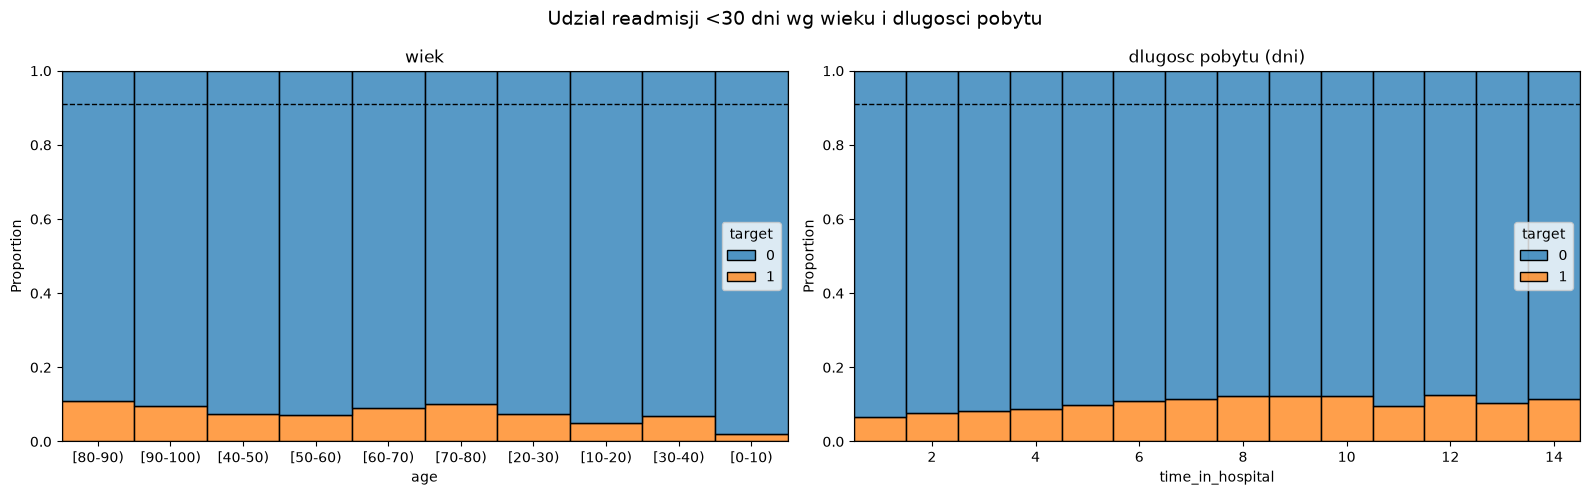

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Udzial readmisji <30 dni wg wieku i dlugosci pobytu", fontsize=14)

# multiple="fill" zamiast "stack": klasa 1 to ~9%, wiec przy "stack" oba wykresy
# wygladalyby identycznie. "fill" normalizuje slupki do 1 -> widac UDZIAL, czyli sygnal.
sns.histplot(
    data=cohort, x="age", hue="target", multiple="fill", stat="proportion", ax=axes[0]
)  # age to string/kategoria -> bez bins
axes[0].axhline(1 - BASELINE, ls="--", c="black", lw=1)  # linia odniesienia = baseline
axes[0].set_title("wiek")

sns.histplot(
    data=cohort,
    x="time_in_hospital",
    hue="target",
    multiple="fill",
    stat="proportion",
    bins=14,
    discrete=True,
    ax=axes[1],
)
axes[1].axhline(1 - BASELINE, ls="--", c="black", lw=1)
axes[1].set_title("dlugosc pobytu (dni)")

fig.tight_layout()

#### Corelation heatmap

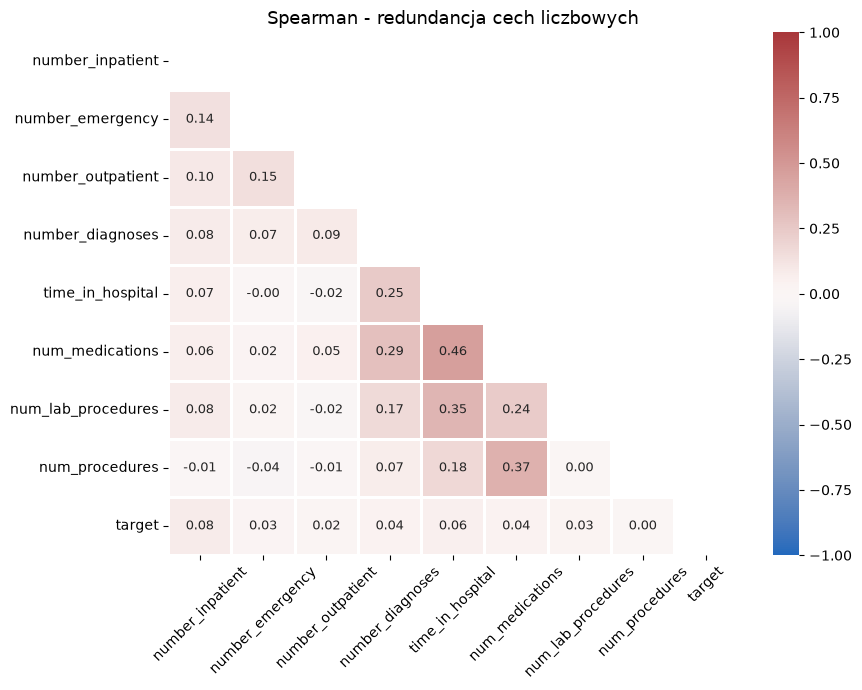

In [15]:
# Korelacja TYLKO na prawdziwie liczbowych. ID-ki i kody kategorii out -
# "kod wypisu 25 > kod 3" nie ma sensu, wiec korelacja na nich to artefakt.
corr = cohort[NUM_COLS + ["target"]].corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title("Spearman - redundancja cech liczbowych", fontsize=13)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 9},
    linewidths=2,
    linecolor="white",
    ax=ax,
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

### 8 · Leakage check

**Moment predykcji = wypis pacjenta.** Cecha jest legalna tylko wtedy, gdy jej wartość
jest znana w tej chwili i nie została uzupełniona później (np. przy rozliczeniu z płatnikiem).

Trzy rodzaje przecieku w tym zbiorze:

1. **Jawny** — `readmitted` jest źródłem targetu, więc w cechach byłoby predykcją idealną.
2. **Identyfikatory** — `encounter_id` rośnie z czasem, `patient_nbr` identyfikuje osobę.
   Model nauczyłby się konkretnych pacjentów zamiast mechanizmu.
3. **Ukryty, administracyjny** — `payer_code` bywa uzupełniany po rozliczeniu, czyli
   *po* zdarzeniu, które przewidujemy. Podobnie `discharge_disposition_id = 12`
   („Still patient or expected to return") częściowo opisuje wynik, a nie stan przy wypisie.

In [16]:
NIGDY_W_MODELU = ["readmitted", "target", "encounter_id", "patient_nbr"]

# Skan automatyczny: rozpietosc = najwyzszy minus najnizszy odsetek readmisji
# miedzy kategoriami. Blisko 1.0 -> cecha zdradza wynik. Umiarkowana -> mocny predyktor.
rows = []
for c in cohort.columns:
    if c in NIGDY_W_MODELU or cohort[c].nunique(dropna=False) > 60:
        continue
    g = cohort.groupby(c, dropna=False)["target"].agg(n="size", rate="mean")
    g = g[g["n"] >= 100]
    if len(g) < 2:
        continue
    rows.append(
        {
            "kolumna": c,
            "grup": len(g),
            "min_rate": g["rate"].min(),
            "max_rate": g["rate"].max(),
            "rozpietosc": g["rate"].max() - g["rate"].min(),
        }
    )

scan = pd.DataFrame(rows).sort_values("rozpietosc", ascending=False)
print(f"baseline = {BASELINE:.3f}   (rozpietosc >0.5 = czerwona lampka)\n")
print(scan.round(3).head(12).to_string(index=False))

# Kontrola konkretnych podejrzanych
print("\n--- discharge_disposition_id == 12 (Still patient / expected to return) ---")
print(
    cohort.loc[cohort["discharge_disposition_id"] == 12, "target"]
    .agg(["size", "mean"])
    .round(3)
    .to_string()
)

baseline = 0.090   (rozpietosc >0.5 = czerwona lampka)

                 kolumna  grup  min_rate  max_rate  rozpietosc
discharge_disposition_id    11     0.031     0.264       0.233
        number_inpatient     6     0.081     0.284       0.203
                     age    10     0.020     0.108       0.088
        number_diagnoses     9     0.031     0.100       0.069
     admission_source_id     9     0.081     0.140       0.059
        time_in_hospital    14     0.065     0.124       0.059
              payer_code    14     0.043     0.099       0.056
             glimepiride     4     0.085     0.132       0.047
        number_emergency     4     0.087     0.134       0.047
               glipizide     4     0.089     0.129       0.041
            pioglitazone     3     0.086     0.118       0.032
               metformin     4     0.070     0.101       0.032

--- discharge_disposition_id == 12 (Still patient / expected to return) ---
size    2.0
mean    0.5
